# Statistical Analysis of Employee Attrition (IBM HR Dataset)

Applying hypothesis tests in Python to answer 5 business questions.

**Significance level (α) = 0.05.** If p < 0.05, we reject H0; otherwise, we fail to reject H0.

In [42]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('Statistics_practice_HR.csv')
print(df.head())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [44]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [45]:
df['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


In [46]:
df['Gender'].value_counts()

,count
Gender,
Male,882
Female,588


In [47]:
df['MonthlyIncome'].describe()

,MonthlyIncome
count,1470.000000
mean,6502.931293
std,4707.956783
min,1009.000000
25%,2911.000000
50%,4919.000000
75%,8379.000000
max,19999.000000


Accept Null Hypothesis


<Axes: xlabel='Gender', ylabel='MonthlyIncome'>

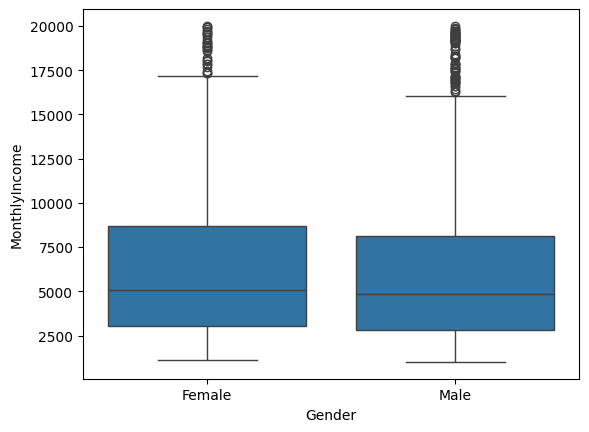

In [48]:
## Test 1: Gender vs MonthlyIncome (Two-sample t-test)

### Hypothesis
  ##H0: The average monthly income of male and female employees is equal.
  ##H1: The average monthly income of male and female employees is different.

###Test:
Male = df[df['Gender']=='Male']['MonthlyIncome']
Female = df[df['Gender']=='Female']['MonthlyIncome']
stats.ttest_ind(Male,Female)
if stats.ttest_ind(Male,Female)[1]<0.05:
    print("Reject Null Hypothesis")
else:
    print("Accept Null Hypothesis")

### Supporting Check: Average Income by Gender
df.groupby('Gender')['MonthlyIncome'].mean()

### Visualization
sns.boxplot(x='Gender',y='MonthlyIncome',data=df)

### Conclusion
### p-value (0.22) > 0.05, so we fail to reject H0. There is no statistically significant difference in average monthly income between male and female employees.

### Insight: No gender pay gap is visible in this dataset.


Reject Null Hypothesis


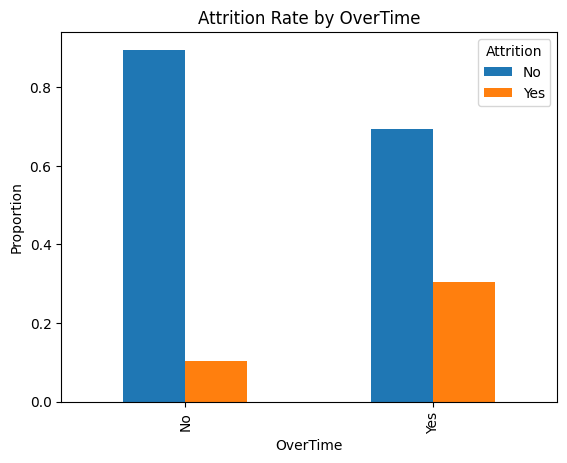

In [49]:
## Test 2: OverTime vs Attrition (Chi-square test)
### Hypothesis
  ##H0: OverTime and Attrition are independent (no relationship).
  ##H1: OverTime and Attrition are related.

###Test:
pd.crosstab(df['OverTime'],df['Attrition'], normalize='index')
stats.chi2_contingency(pd.crosstab(df['OverTime'],df['Attrition']))
if stats.chi2_contingency(pd.crosstab(df['OverTime'],df['Attrition']))[1]<0.05:
    print("Reject Null Hypothesis")
else:
    print("Accept Null Hypothesis")

###Visualization
pd.crosstab(df['OverTime'], df['Attrition'], normalize='index').plot(kind='bar')
plt.title('Attrition Rate by OverTime')
plt.ylabel('Proportion')
plt.show()

### Conclusion
### p-value < 0.05, so we reject H0. OverTime and Attrition have a significant relationship.

### Insight: Employees working overtime leave at about 30%, compared to about 10% for those who don't. HR could review overtime workload to improve retention.

Reject Null Hypothesis


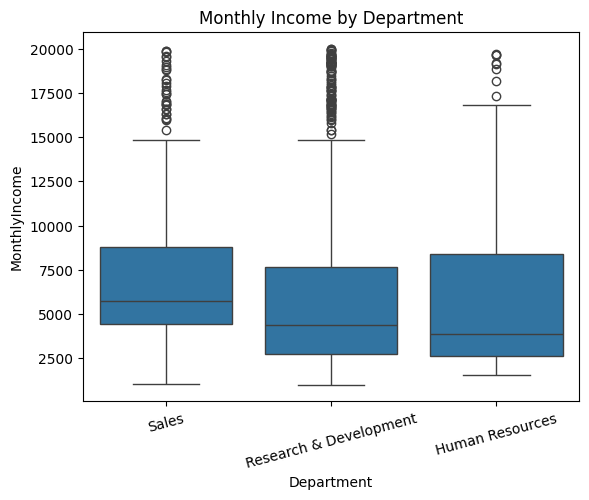

In [50]:
## Test 3: Department vs MonthlyIncome (One-way ANOVA)
### Hypothesis
  ##H0: The average monthly income is the same across all departments.
  ##H1: The average monthly income differs in at least one department.

###Test:
sales = df[df['Department']=='Sales']['MonthlyIncome']
research = df[df['Department']=='Research & Development']['MonthlyIncome']
accounting = df[df['Department']=='Human Resources']['MonthlyIncome']
anova,P_value = stats.f_oneway(sales,research,accounting)
if P_value<0.05:
    print("Reject Null Hypothesis")
else:
    print("Accept Null Hypothesis")

###Supporting Check: Department vs MonthlyIncome
df.groupby('Department')['MonthlyIncome'].mean()

###Visualization
sns.boxplot(x='Department', y='MonthlyIncome', data=df)
plt.title('Monthly Income by Department')
plt.xticks(rotation=15)
plt.show()

### Conclusion
### p-value < 0.05, so we reject H0. Average monthly income differs significantly across departments.

### Insight: Human Resources has the highest average income (6654.50), while Sales has the lowest (6959.17).

Reject Null Hypothesis


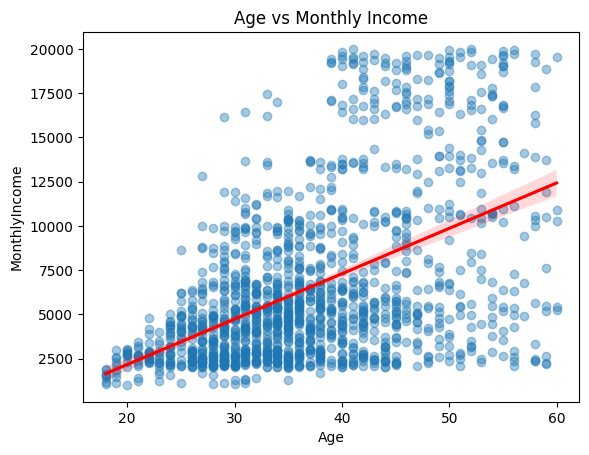

In [53]:
## Test 4: Age vs MonthlyIncome (Pearson Correlation)
### Hypothesis
  ##H0:** There is no linear relationship between Age and MonthlyIncome (r = 0).
  ##H1:** There is a linear relationship between Age and MonthlyIncome (r ≠ 0).

###Test:
T_valuep, r = stats.pearsonr(df['Age'],df['MonthlyIncome'])
if r<0.05:
  print('Reject Null Hypothesis')
else:
  print('Not Reject Null Hypothesis')

###Visualization
sns.regplot(x='Age', y='MonthlyIncome', data=df, scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
plt.title('Age vs Monthly Income')
plt.show()

### Conclusion
### p-value < 0.05, so we reject H0. Age and MonthlyIncome have a significant moderate positive correlation (r ≈ 0.50).

### Insight: Older employees tend to earn more, though correlation does not imply causation (experience and job level likely play a role).

4.095763375378081 4.437238127674775e-05
Reject Null Hypothesis


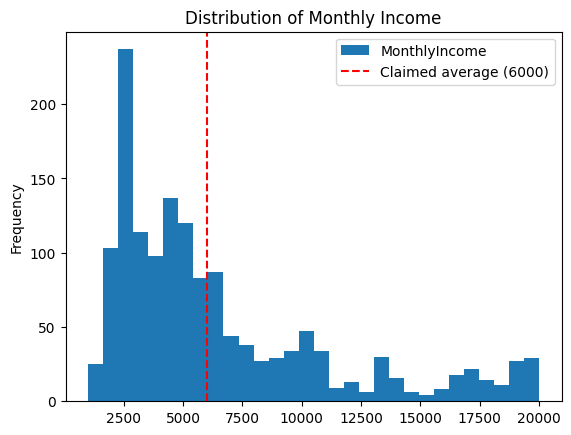

In [52]:
## Test 5: Average MonthlyIncome vs 6000 (One-sample t-test, two-tailed)
### Hypothesis
  ##H0:** The average monthly income equals 6000 (μ = 6000).
  ##H1:** The average monthly income is not equal to 6000 (μ ≠ 6000).

###Test:
T_value, P_value = stats.ttest_1samp(df['MonthlyIncome'], 6000)
print(T_value, P_value)
if P_value<0.05:
  print('Reject Null Hypothesis')
else:
  print('Not Reject Null Hypothesis')

###Suporting Check
df['MonthlyIncome'].mean()

###Vosualization
df['MonthlyIncome'].plot(kind='hist', bins=30)
plt.axvline(6000, color='red', linestyle='--', label='Claimed average (6000)')
plt.legend()
plt.title('Distribution of Monthly Income')
plt.show()

### Conclusion
### p-value < 0.05, so we reject H0. The average monthly income is significantly different from 6000.

### Insight: The actual average (6502.93) is above the claimed 6000.